## Project P629 : Resume classification

Objective : Build and deployment of Resume classification

### Imports

In [1]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 97.8 MB/s eta 0:00:00


In [2]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.6 MB/s eta 0:00:00


In [3]:
pip install docx2txt


In [4]:
!pip install wordcloud

In [5]:
import sys
print(sys.executable)


/usr/bin/python3


In [6]:
import sys
!{sys.executable} -m pip install wordcloud



In [7]:
# =========================
# CORE LIBRARIES
# =========================
import pandas as pd          # Data handling using DataFrames (used throughout the project)
import numpy as np           # Numerical operations (arrays, math support)
import re                    # Regular expressions for text cleaning
import string                # String constants (punctuation removal)

# =========================
# VISUALIZATION
# =========================
import matplotlib.pyplot as plt   # Basic plotting (EDA, PCA plots, charts)
import seaborn as sns             # Advanced statistical plots (boxplots, heatmaps)

# =========================
# NLP UTILITIES
# =========================
import nltk                       # Natural Language Toolkit (tokenization, stopwords)
from nltk.corpus import stopwords # Stopword removal during text preprocessing
from collections import Counter   # Frequency counting (skill extraction, top words)
from wordcloud import WordCloud   # Word cloud visualization (EDA – skill overview)
from sklearn.metrics.pairwise import cosine_similarity # Resume similarity analysis

# =========================
# FEATURE ENGINEERING
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer
# Converts resume text into numerical TF-IDF features (used for similarity & classification)

# =========================
# MODELING & EVALUATION
# =========================
from sklearn.model_selection import train_test_split
# Splits data into training and testing sets

from sklearn.metrics import classification_report, confusion_matrix
# Evaluates classification model performance

# =========================
# DIMENSIONALITY REDUCTION
# =========================
from sklearn.decomposition import PCA
# Reduces high-dimensional TF-IDF features for visualization (resume similarity plot)

# =========================
# LABEL ENCODING
# =========================
from sklearn.preprocessing import LabelEncoder
# Converts role labels (text) into numeric form for classification models


## Read the data

In [9]:
import zipfile

zip_file_path = 'P629_DATASET.zip'
extraction_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted successfully to '{extraction_path}'")

'P629_DATASET.zip' extracted successfully to './'


In [10]:
#Check the folders
import os       #The os module is used to navigate directories and access resume files stored in different folders.

os.listdir(r'/content/P629_DATASET/Resumes')




['Internships',
 'SQL Developer Lightning insight',
 'Developer',
 'Peoplesoft resumes',
 'workday resumes']

In [11]:
#Importing Text Extraction Libraries

#we used python-docx to read Word files and pdfplumber to extract text from PDFs.
#Different libraries are needed because file formats differ.”

In [12]:
!pip install python-docx pdfplumber


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.6 MB/s eta 0:00:00


In [ ]:
import sys
!{sys.executable} -m pip install python-docx


In [ ]:
import sys
!{sys.executable} -m pip install pdfplumber


In [ ]:
!apt-get update -qq
!apt-get install -y libreoffice

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libreoffice is already the newest version (1:7.3.7-0ubuntu0.22.04.10).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [13]:
import os
import subprocess

base_folder = "/content/P629_DATASET/Resumes"

converted = 0
failed = 0

for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.lower().endswith(".doc") and not file.lower().endswith(".docx"):
            doc_path = os.path.join(root, file)
            try:
                subprocess.run([
                    "soffice",
                    "--headless",
                    "--convert-to",
                    "docx",
                    doc_path,
                    "--outdir",
                    root
                ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

                converted += 1
            except:
                failed += 1

print("DOC files converted to DOCX:", converted)
print("Conversion failures:", failed)


DOC files converted to DOCX: 0
Conversion failures: 26


In [14]:
# counting files in each role(folder)
base_folder = "/content/P629_DATASET/Resumes"

doc_count = 0
docx_count = 0
pdf_count = 0
other_count = 0

for root, dirs, files in os.walk(base_folder):
    for file in files:
        file_lower = file.lower()

        if file_lower.endswith(".doc") and not file_lower.endswith(".docx"):
            doc_count += 1
        elif file_lower.endswith(".docx"):
            docx_count += 1
        elif file_lower.endswith(".pdf"):
            pdf_count += 1
        else:
            other_count += 1

print("DOC files :", doc_count)
print("DOCX files:", docx_count)
print("PDF files :", pdf_count)
print("Other files:", other_count)
print("Total files:", doc_count + docx_count + pdf_count + other_count)

#“This block
#counts how many DOC, DOCX, and PDF files are present.
#This is important because different formats require different handling.
#For example, PDFs and DOCX need different libraries to extract text.”

#and aslso
#prints the file count summary.
#It helps verify whether the resume dataset is balanced and ready for processing

DOC files : 26
DOCX files: 52
PDF files : 1
Other files: 0
Total files: 79


In [15]:
#reading all resumes and creating a DF

!pip install python-docx
from docx import Document
import pdfplumber

base_folder = "/content/P629_DATASET/Resumes"

data = []
total_files = 0
read_files = 0
skipped_files = 0

for root, dirs, files in os.walk(base_folder):
    for file in files:
        total_files += 1
        file_path = os.path.join(root, file)
        text = ""

        # ---------- READ DOCX ----------
        if file.lower().endswith(".docx"):
            try:
                doc = Document(file_path)
                text = " ".join(p.text for p in doc.paragraphs)
                read_files += 1
            except:
                skipped_files += 1
                continue

        # ---------- READ PDF ----------
        elif file.lower().endswith(".pdf"):
            try:
                with pdfplumber.open(file_path) as pdf:
                    text = " ".join(page.extract_text() or "" for page in pdf.pages)
                read_files += 1
            except:
                skipped_files += 1
                continue

        # ---------- IGNORE .DOC & OTHERS ----------
        else:
            skipped_files += 1
            continue

        role = os.path.relpath(root, base_folder).split(os.sep)[0]

        if text.strip():
            data.append({
                "resume_text": text,
                "role": role
            })

df = pd.DataFrame(data)

#print("Total files found        :", total_files)
print("Readable resumes loaded  :", read_files)
print("Files skipped (.doc etc) :", skipped_files)
print("Final resumes in df      :", df.shape[0])
df.head()


#Resume Text Extraction
#This block reads resumes, extracts text, and assigns job roles based on folder names.
#For example, resumes inside the ‘Data Scientist’ eradicate labeled as that role.

#Creating Resume DataFrame
#All extracted resume text and role labels are stored in a Pandas DataFrame.
#This makes analysis and processing easier.”

#Resume Loading Statistics
#This prints how many resumes were read and skipped.
#It helps confirm that data loading was successful.”

Readable resumes loaded  : 53
Files skipped (.doc etc) : 26
Final resumes in df      : 53


,resume_text,role
0,Name: Ravali P ...,Internships
1,SUSOVAN BAG Seeking a challenging po...,Internships
2,RAJU PAVANA KUMARI Professional Summary: Ha...,SQL Developer Lightning insight
3,KAMBALLA PRADEEP ...,SQL Developer Lightning insight
4,ANIL KUMAR MADDUKURI \t\t SQL & MSBI Develope...,SQL Developer Lightning insight


## EDA

In [16]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)

Dataset Shape: (53, 2)

Column Names:
 Index(['resume_text', 'role'], dtype='object')


In [17]:
df['role'].value_counts()

,count
role,
Developer,19
workday resumes,11
SQL Developer Lightning insight,11
Peoplesoft resumes,10
Internships,2


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   resume_text  53 non-null     object
 1   role         53 non-null     object
dtypes: object(2)
memory usage: 980.0+ bytes


In [ ]:
#Check null values
#df.isnull().sum()

In [ ]:
#duplicate
#print("Duplicate resumes found:",
      #df.duplicated(subset=['role', 'resume_text']).sum())

###### duplicate

In [19]:
# Calculate the length (number of characters) of each resume text
df['text_len'] = df['resume_text'].str.len()

# Group rows by resume_text and check
# how many different text lengths exist for the same resume text
# (helps detect hidden/invisible differences in extracted text)
df.groupby('resume_text')['text_len'] \
  .nunique() \
  .sort_values(ascending=False) \
  .head()

#This code checks for invisible differences in resume text.
#It calculates the length of each resume and then finds cases where the same resume text appears with
 #different character lengths,
 #indicating hidden spaces, line breaks, or extraction inconsistencies that affect duplicate detection.

resume_text
\t   Name         : Gopi Krishna Reddy \t\t                         PROFESSIONAL SUMMERY: Working as a Workday Consultant with 3+ years as Workday Consultant and good experience on Report Writing, Integration of HCM.   Knowledge of the software development life cycle from design through scoping, requirements gathering, analysis, development, testing, user acceptance, deployment, maintenance/support and change management.  Good working knowledge on Inbound and Outbound EIB Integration concepts and created various EIB Integrations. Building Core Connector integrations for extracting worker, position, status, leave and absence delta changes. Designed and built all types of integrations using Document Transformation, EIB, PICOF, Cloud Connectors and Custom Report Writer.  Having  good knowledge on Workday Studio  Experience with XML, XPATH and XSLT and Expert in designing/development of Interfaces with legacy and third party systems.  Hands-on experience In Migrating the XSLT Code, Reports from Lower tenant to Sandbox and Production using Object Transporter. Experienced in developing Custom Reports, Advanced Reports using Report Writer. Strong experience using technologies involving Workday applications, reporting and analytics.  Good experience on create Report Groups and Workbooks to create Excel worksheet groups and create Dashboards. Strong Knowledge on working with CR-Change Requests as per business requirement and Building and moving changes to production. Worked closely with Business and Development Teams for Designed and Documented Enhancements as well as conducted Production Support Troubleshooting around Integrations for Global Workday HCM System. Excellent Interpersonal, Presentation and Communication Skills with the ability to work in a team and a Stand-alone Environment.  EDUCATIONAL DETAILS:  Completed Bachelor of Degree from JNTU - K University in 2014.  TECHNICAL SKILLS:              PROJECT DETAILS:            Company: Tyson Foods, Bangalore                 (May 2018 to Present) Project: Workday Support and Enhancement\t\t\t\t\t\t\t Role: Workday Technical Consultant  Responsibilities: Involved in Workday HCM for various HR modules such as Benefits, Compensation, Time Tracking and Absence Management. Worked on Calculated Fields to create Report level and Global level. Monitor daily Schedulers and Report Errors as needed. Design and Build Integrations and worked closely with testing and production teams to solve issues with integrations. Created Custom Reports like Simple, Advanced Reports as per the client requirements and shared with the security groups. Created Reports against the Worker business object and worked on Headcount, Turnover and Compensation Reports. Good experience with Core Connector Worker to work on Employee Demographics and build Benefit Integrations and Account Provisioning Integrations. Created Inbound/Outbound integrations using Workday Studio, Core/Cloud Connectors, EIB’s and Document Transformation Process. Involved in Unit Test on Integrations, UAT support and end user training. Design, build or maintain integrations of all types: Reports, EIB, Core Connectors, Payroll Connectors or Studio. Write / Modify Technical Design/ Specifications as needed Participate in Integration Testing and Peer Testing. Work independently or with minimal supervision with various Stakeholders including the Functional Consultants. Monitor and update ticketing tool on daily basis. Manage work activities and ticket volumes to meet required SLA’s and service delivery measures. Developed Core Connector and Document Transformation integrations to get changes file of CSV format from XML Output.   Used sequence generators, generating templates and validating inbound integration system results. Day to day support for Workday HCM, Integrations and Reporting issues.  Technical Environment: Workday 30/31/32, Workday Studio, Workday EIB, Workday BIRT, Core Concepts, Document Transformation, Calculated Fields, Ox

In [20]:

# Normalize resume text (whitespace only) to create a stable key for duplicate detection
df['resume_text_dedup'] = (
    df['resume_text']
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)


In [21]:
print("Duplicate resumes found:",
      df.duplicated(subset=['role','resume_text_dedup']).sum())

Duplicate resumes found: 2


In [22]:
df[df.duplicated(subset='resume_text_dedup', keep=False)]

,resume_text,role,text_len,resume_text_dedup
17,MAREEDU LOKESH BABU PROFESSIONAL OVERVIEW A...,Developer,2912,MAREEDU LOKESH BABU PROFESSIONAL OVERVIEW Arou...
22,MAREEDU LOKESH BABU PROFESSIONAL OVERVIEW ...,Developer,2913,MAREEDU LOKESH BABU PROFESSIONAL OVERVIEW Arou...
24,Ui-Developer/ React JS Developer NAME: KRISH...,Developer,3634,Ui-Developer/ React JS Developer NAME: KRISHNA...
27,Ui-Developer/ React JS Developer NAME: KRISH...,Developer,3633,Ui-Developer/ React JS Developer NAME: KRISHNA...


In [23]:
df = df.drop_duplicates(
    subset=['role', 'resume_text_dedup']
).reset_index(drop=True)


In [24]:
df = df.drop(columns=['resume_text_dedup', 'text_len'])

In [25]:
print("Dataset Shape:", df.shape)

Dataset Shape: (51, 2)


In [26]:
df['role'].value_counts()

,count
role,
Developer,17
workday resumes,11
SQL Developer Lightning insight,11
Peoplesoft resumes,10
Internships,2


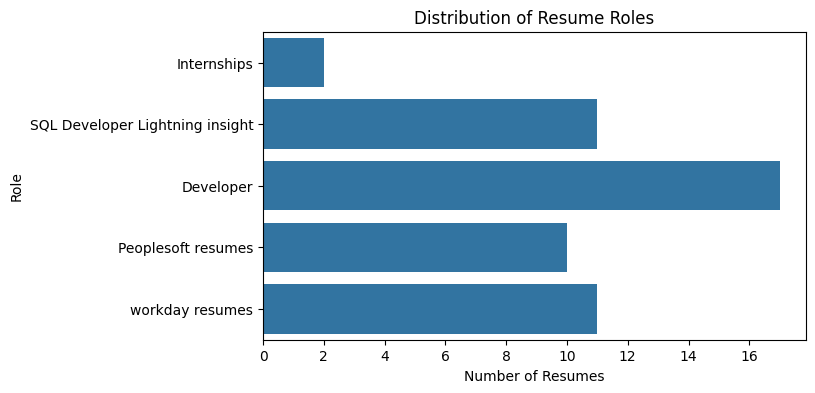

In [27]:
plt.figure(figsize=(7,4))
sns.countplot(y=df['role'])
plt.title("Distribution of Resume Roles")
plt.xlabel("Number of Resumes")
plt.ylabel("Role")
plt.show()


In [28]:
#df[df.duplicated(subset='resume_text', keep=False)]


In [29]:
#Delete duplicates
#df = df.drop_duplicates(subset=['role', 'resume_text'])


In [30]:
#print("Dataset Shape:", df.shape)

#### Text based EDA

In [31]:
#Resume Length Analysis

df1 = df[['role', 'resume_text']].copy()

df1['char_length'] = df1['resume_text'].apply(len)
df1['word_count'] = df1['resume_text'].apply(lambda x: len(x.split()))

df1.groupby('role')[['char_length', 'word_count']].mean().round(2)


#calculated character and word counts to analyze resume length.
#This helps compare resume patterns across roles.”


,char_length,word_count
role,,
Developer,2494.76,339.12
Internships,2582.50,232.00
Peoplesoft resumes,5168.20,702.20
SQL Developer Lightning insight,4013.27,553.27
workday resumes,5692.91,766.18


In [32]:
#Overall Most Common Words (Raw)

all_words = ' '.join(df['resume_text']).lower().split()
Counter(all_words).most_common(20)   #twenty words only


[('and', 1358),
 ('the', 745),
 ('in', 678),
 ('to', 601),
 ('of', 496),
 ('on', 349),
 ('for', 348),
 ('experience', 283),
 (':', 267),
 ('using', 231),
 ('as', 215),
 ('with', 212),
 ('workday', 181),
 ('a', 169),
 ('from', 168),
 ('application', 157),
 ('data', 154),
 ('business', 144),
 ('sql', 138),
 ('peoplesoft', 135)]

## Preprocessing, NLP/Text mining

In [33]:
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [34]:
#tokenization (splits text into tokens)

from nltk.tokenize import word_tokenize

df['resume_text'] = df['resume_text'].apply(word_tokenize)


In [35]:
# Download stopwords (run once)
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [36]:
#this code is to remove words which are not getting deleted by stopword
resume_stopwords = {
    # action verbs
    "using", "used", "working", "worked", "created", "identified",

    # generic resume fillers
    "experience", "knowledge", "skills", "good", "best", "various",

    # role/self identifiers
    "developer", "internship", "people", "name",

    # project / process words
    "project", "projects", "process", "processes",
    "system", "systems", "application", "applications",
    "support", "business", "organization", "meeting",

    # vague technical wrappers
    "technologies", "tools", "domains", "services",

    # linguistic noise
    "like",

    "years","front",

    # vague / buzzwords
    "extreme", "utilize", "globalization",

    # academic / generic
    "science", "management", "concepts", "method",

    # personal names
    "ravali",

    # training / education noise
    "training", "certified", "understanding",

    # language & contact noise
    "english", "telugu", "hindi", "languages", "com"

     # process / environment noise
    "involved", "client", "environment", "environments", "production",

    # generic infra terms (optional but recommended)
    "server","servers", "web", "data", "load"

    # action / process noise
    "creating", "development", "sub","developed", "involved", "calculated",

       # role / context
    "client", "consultant",

    # vague technical
    "custom"
}


In [37]:
#Stopword and Further cleaning data

stop_words = set(stopwords.words('english')).union(resume_stopwords)

def clean_resume(text):
    # safety check
    if isinstance(text, list):
        text = ' '.join(text)  #Handles cases where text is accidentally a list of tokens

    text = text.lower()     #Lowercasing
    text = re.sub(r'\d+', ' ', text) #Remove numbers
    text = re.sub(r'[^a-zA-Z ]', ' ', text)  #Remove special characters-Removes punctuation and symbols

    words = [w for w in text.split() if w not in stop_words and len(w) > 2]   #Removes Stopword + short-word removal
    return ' '.join(words)      #Return clean text

#Apply cleaning to the dataset
df['resume_text'] = df['resume_text'].apply(clean_resume)

# overview
# Resume text is cleaned by lowercasing, removing noise, stopwords,
# and retaining only meaningful skill-related terms.


In [38]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [39]:
#lemmatizing
#Lemmatization converts words to their meaningful base form using vocabulary and context,
#so related word forms are treated as the same

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = text.split()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lemmatized_tokens)

df['clean_resume'] = df['resume_text'].apply(lemmatize_text)


In [40]:
df.head()

,resume_text,role,clean_resume
0,curriculum vitae specialization computer engg ...,Internships,curriculum vitae specialization computer engg ...
1,susovan bag seeking challenging position field...,Internships,susovan bag seeking challenging position field...
2,raju pavana kumari professional summary profes...,SQL Developer Lightning insight,raju pavana kumari professional summary profes...
3,kamballa pradeep synopsis looking forward aspi...,SQL Developer Lightning insight,kamballa pradeep synopsis looking forward aspi...
4,anil kumar maddukuri sql msbi summary sql ssms...,SQL Developer Lightning insight,anil kumar maddukuri sql msbi summary sql ssms...


#### Comments
###### Personal identifiers such as names may appear in resumes;
###### they are treated as low-frequency tokens and do not affect model performance.

🧠 What is ACCEPTABLE in projects

✔ Having a few names left is NOT a problem
✔ Models learn skills, not names
✔ TF-IDF naturally downweights rare names

Most real resume pipelines do not perfectly remove names.

##### ✅Named Entity Recognition (NER)

- Using spaCy to remove PERSON entities
- ⚠️ Overkill for most resume-classification projects

##### ✅POS
- POS tagging was not used to remove names **since technical skills and tools are often tagged as proper nouns and may be lost**.

#### Average skill density &  Resume length distribution

In [41]:
#Average skill density

df2 = df[['role', 'clean_resume']].copy()

df2['word_count'] = df2['clean_resume'].apply(lambda x: len(x.split()))
df2['unique_words'] = df2['clean_resume'].apply(lambda x: len(set(x.split())))
df2['skill_density'] = df2['unique_words'] / df2['word_count']

df2.groupby('role')[['word_count', 'unique_words', 'skill_density']].mean()

#Skill density is calculated as unique words divided by total words.
#It shows how rich a resume is in skills. Higher density means more diverse skills.”


,word_count,unique_words,skill_density
role,,,
Developer,187.176471,134.882353,0.739567
Internships,116.500000,97.000000,0.835537
Peoplesoft resumes,367.000000,172.200000,0.543848
SQL Developer Lightning insight,318.181818,194.363636,0.637268
workday resumes,433.727273,231.272727,0.542320


📝 Resume Complexity & Skill Density Analysis

This analysis compares resume length and vocabulary richness across different roles.

- Word Count represents the average resume length.

- Unique Words indicate vocabulary diversity used within resumes.

- Skill Density (unique words ÷ total words) reflects how concentrated the resume is with distinct skills.

##### Observations:

- Internship resumes are **shorter but highly focused**, **showing the highest skill density**.

- PeopleSoft and Workday resumes are **longer and more descriptive**, resulting in **lower skill density**.

- React Developer resumes balance **moderate length** with relatively **high skill concentration**.

- SQL Developer resumes show structured detail with **medium skill density**.

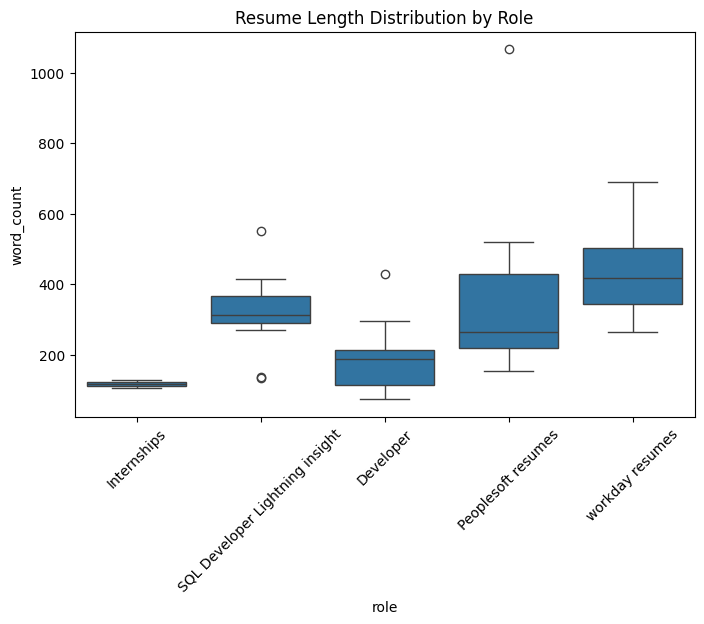

In [42]:
#Resume length distribution
plt.figure(figsize=(8,5))
sns.boxplot(x='role', y='word_count', data=df2)
plt.xticks(rotation=45)
plt.title("Resume Length Distribution by Role")
plt.show()


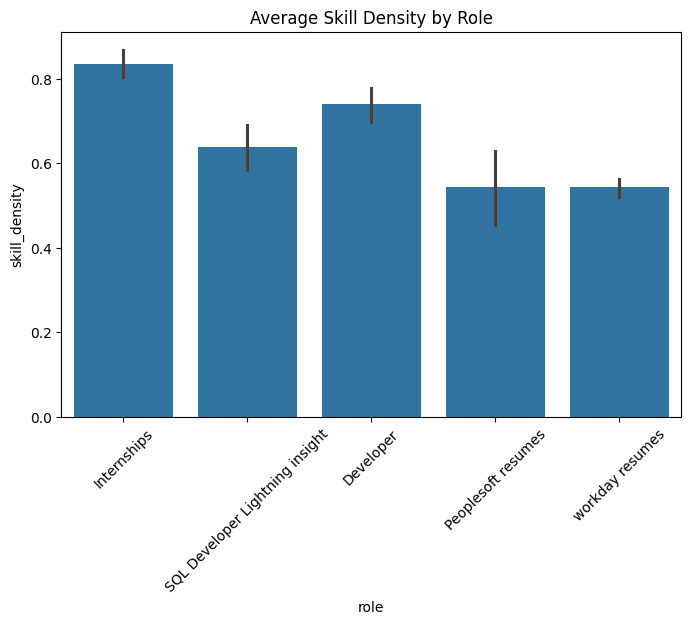

In [43]:
#Average skill density
plt.figure(figsize=(8,5))
sns.barplot(x='role', y='skill_density', data=df2)
plt.xticks(rotation=45)
plt.title("Average Skill Density by Role")
plt.show()


“We analyzed resume length, vocabulary richness, and skill density across different job roles to understand how resume characteristics vary between roles and to validate that each role contains distinct information patterns.”

In [44]:
#Extract skills within each role
from collections import Counter
import re

role_skill_stats = {}

for role in df['role'].unique():
    role_text = ' '.join(df[df['role'] == role]['clean_resume'])

    skills = re.findall(r'\b\w[\w\+\#\.]*\b', role_text)
    skill_counts = Counter(skills)

    role_skill_stats[role] = skill_counts.most_common(20)

#Extracting Top Skills per Role
#This block extracts the most frequent skills within each role using word frequency analysis.
#It helps understand role requirements.”

In [45]:
#View within-role top skills (text output)
for role, skills in role_skill_stats.items():
    print(f"\nTop skills WITHIN {role}:")
    for skill, count in skills:
        print(f"{skill}: {count}")




Top skills WITHIN Internships:
testing: 12
test: 6
case: 4
integration: 3
html: 3
cs: 3
computer: 2
functional: 2
scrum: 2
sprint: 2
product: 2
java: 2
com: 2
linux: 2
fluent: 2
iot: 2
water: 2
motor: 2
controller: 2
book: 2

Top skills WITHIN SQL Developer Lightning insight:
sql: 163
table: 61
database: 54
query: 51
report: 44
function: 39
procedure: 33
index: 33
ssis: 28
stored: 27
view: 27
creating: 25
task: 25
user: 24
role: 23
join: 22
date: 20
requirement: 20
trigger: 20
package: 20

Top skills WITHIN Developer:
react: 89
html: 55
cs: 47
javascript: 38
bootstrap: 26
team: 24
design: 24
work: 23
component: 21
role: 21
developing: 20
software: 19
page: 19
designing: 18
end: 18
date: 16
redux: 16
user: 16
requirement: 16
professional: 16

Top skills WITHIN Peoplesoft resumes:
peoplesoft: 145
scheduler: 48
database: 45
report: 45
oracle: 38
fscm: 34
peopletools: 32
update: 32
role: 29
pum: 27
migration: 26
hcm: 26
user: 26
upgrade: 25
patch: 25
change: 25
load: 25
issue: 24
applying

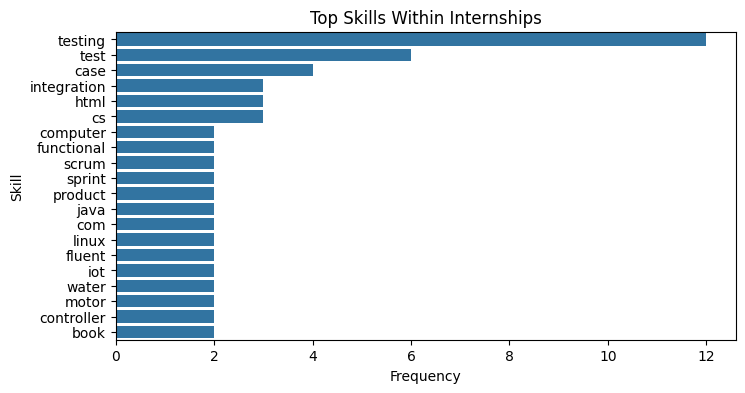

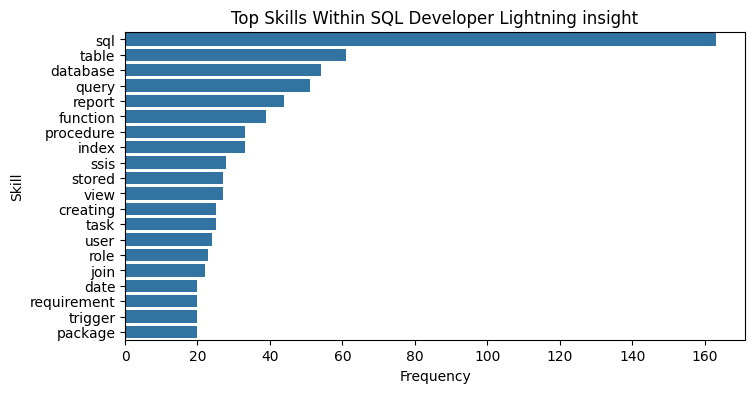

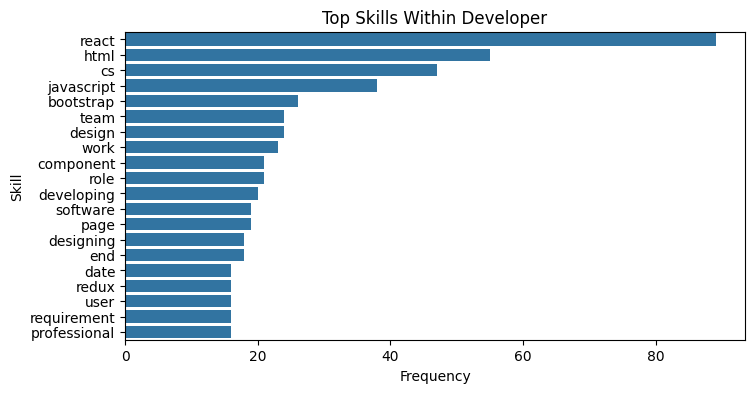

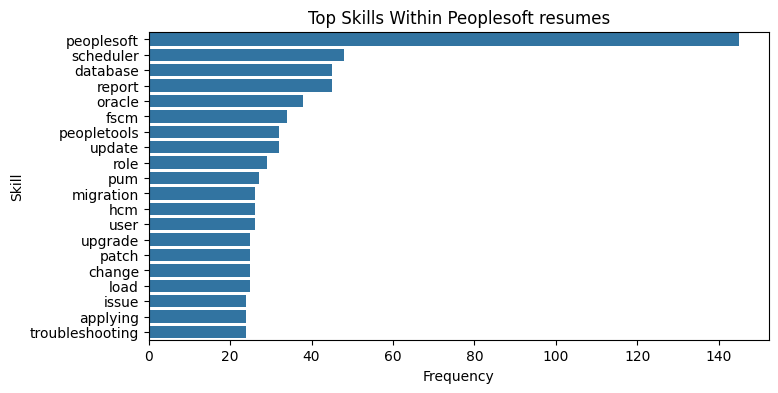

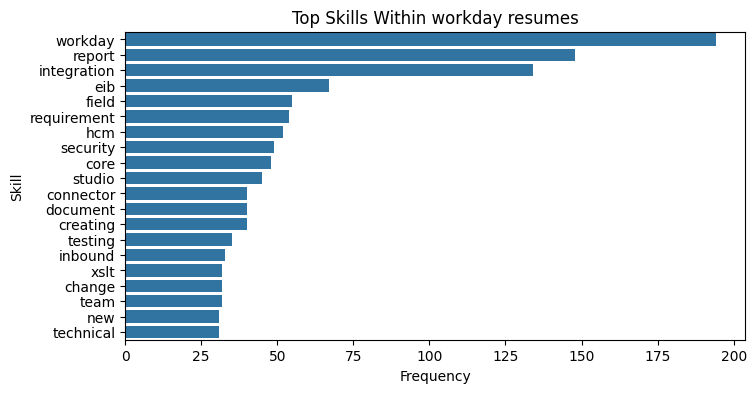

In [46]:
#Visualize within-role skills (BAR PLOT)
for role, skills in role_skill_stats.items():
    skill_df = pd.DataFrame(skills, columns=['skill', 'count'])

    plt.figure(figsize=(8,4))
    sns.barplot(x='count', y='skill', data=skill_df)
    plt.title(f"Top Skills Within {role}")
    plt.xlabel("Frequency")
    plt.ylabel("Skill")
    plt.show()


In [47]:
#Within-role skill diversity

within_role_diversity = df2.groupby('role')['unique_words'].mean().round(0)
within_role_diversity

#what it will give
#“How varied are skills among resumes of the same role”


,unique_words
role,
Developer,135.0
Internships,97.0
Peoplesoft resumes,172.0
SQL Developer Lightning insight,194.0
workday resumes,231.0


In [48]:
#most repeated across all resumes
all_words = ' '.join(df['clean_resume']).lower().split()
Counter(all_words).most_common(20)   #twenty words only


[('report', 238),
 ('workday', 194),
 ('sql', 178),
 ('integration', 170),
 ('peoplesoft', 156),
 ('requirement', 108),
 ('database', 103),
 ('role', 99),
 ('creating', 93),
 ('user', 89),
 ('react', 89),
 ('technical', 82),
 ('design', 82),
 ('hcm', 78),
 ('table', 77),
 ('team', 76),
 ('query', 74),
 ('work', 69),
 ('testing', 68),
 ('responsibility', 68)]

In [ ]:
#Terms like "report" represent functional responsibilities rather than core technical skills.

#### ROLE-WISE SKILL DISCOVERY

In [49]:
#import sys
#!{sys.executable} -m pip install "numpy<2"


In [ ]:
#import sys

#print("Python:", sys.executable)
#print("NumPy version:", np.__version__)


In [ ]:
#import sys
#!{sys.executable} -m pip uninstall -y matplotlib
#!{sys.executable} -m pip install matplotlib==3.8.4


In [ ]:
#plt.imshow(wc.to_image())


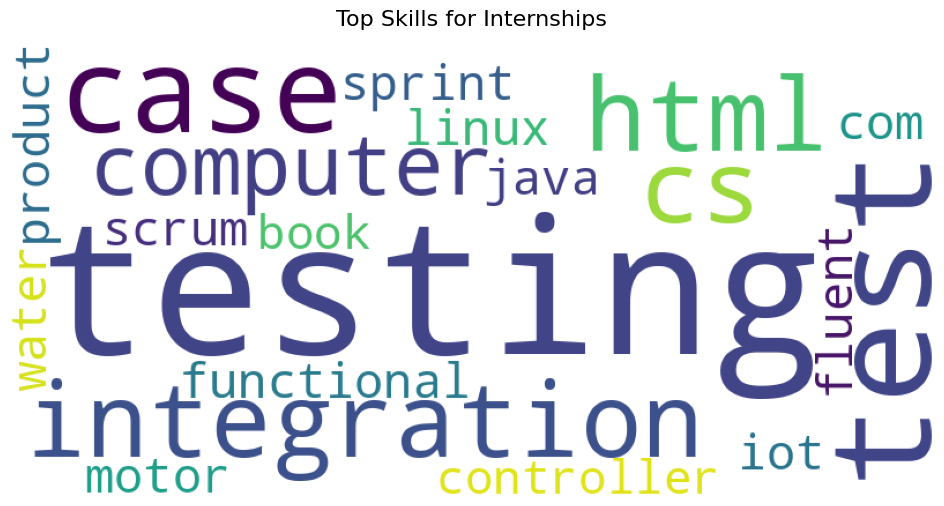

Top skills for Internships: [('testing', 12), ('test', 6), ('case', 4), ('integration', 3), ('html', 3), ('cs', 3), ('computer', 2), ('functional', 2), ('scrum', 2), ('sprint', 2), ('product', 2), ('java', 2), ('com', 2), ('linux', 2), ('fluent', 2), ('iot', 2), ('water', 2), ('motor', 2), ('controller', 2), ('book', 2)]


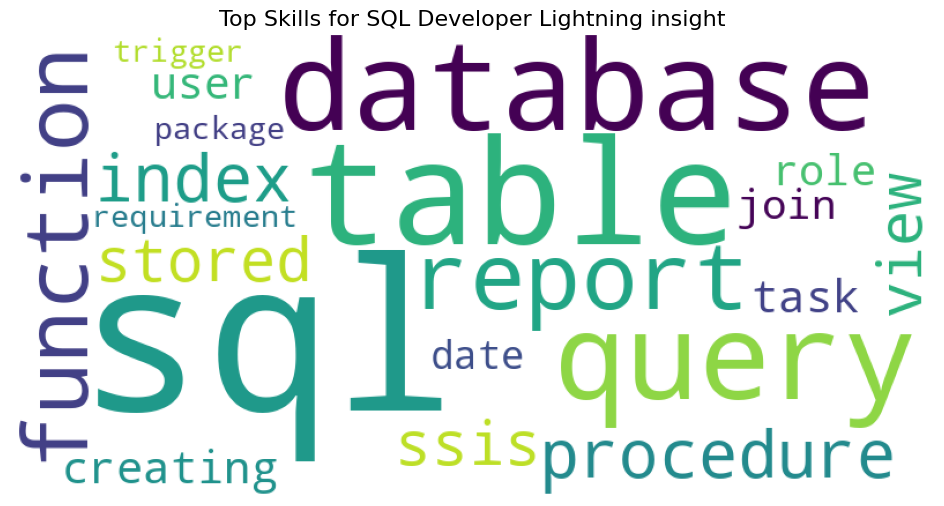

Top skills for SQL Developer Lightning insight: [('sql', 163), ('table', 61), ('database', 54), ('query', 51), ('report', 44), ('function', 39), ('procedure', 33), ('index', 33), ('ssis', 28), ('stored', 27), ('view', 27), ('creating', 25), ('task', 25), ('user', 24), ('role', 23), ('join', 22), ('date', 20), ('requirement', 20), ('trigger', 20), ('package', 20)]


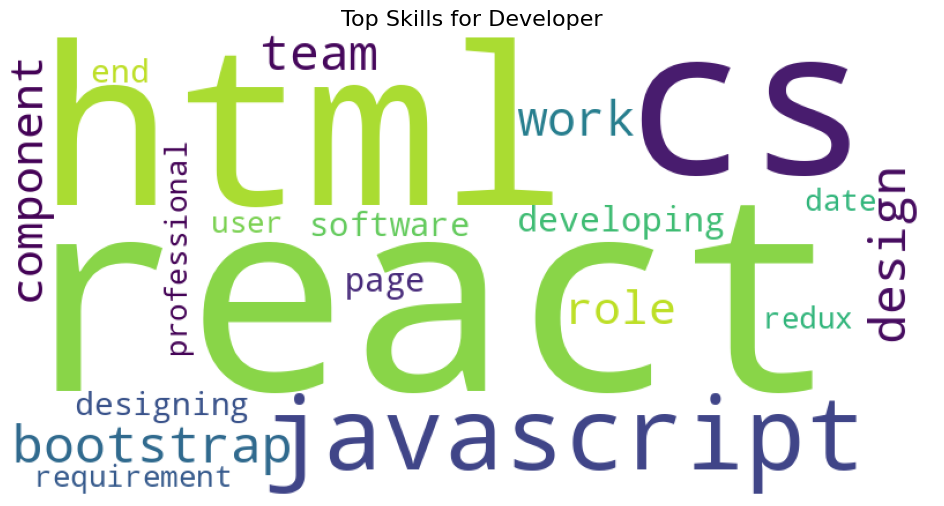

Top skills for Developer: [('react', 89), ('html', 55), ('cs', 47), ('javascript', 38), ('bootstrap', 26), ('team', 24), ('design', 24), ('work', 23), ('component', 21), ('role', 21), ('developing', 20), ('software', 19), ('page', 19), ('designing', 18), ('end', 18), ('date', 16), ('redux', 16), ('user', 16), ('requirement', 16), ('professional', 16)]


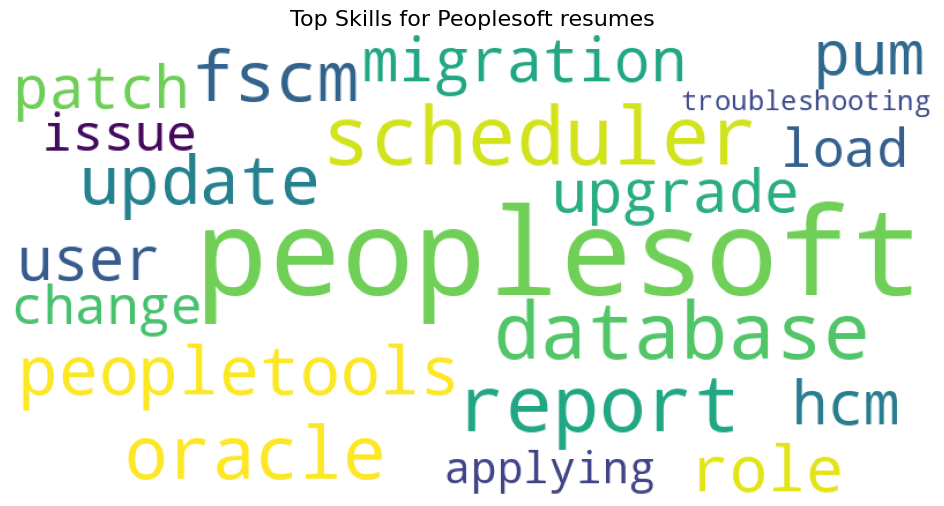

Top skills for Peoplesoft resumes: [('peoplesoft', 145), ('scheduler', 48), ('database', 45), ('report', 45), ('oracle', 38), ('fscm', 34), ('peopletools', 32), ('update', 32), ('role', 29), ('pum', 27), ('migration', 26), ('hcm', 26), ('user', 26), ('upgrade', 25), ('patch', 25), ('change', 25), ('load', 25), ('issue', 24), ('applying', 24), ('troubleshooting', 24)]


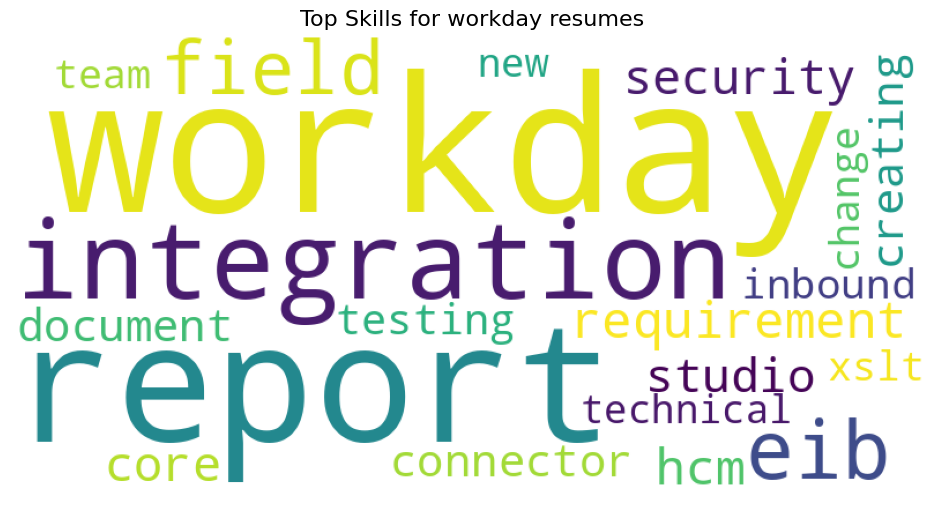

Top skills for workday resumes: [('workday', 194), ('report', 148), ('integration', 134), ('eib', 67), ('field', 55), ('requirement', 54), ('hcm', 52), ('security', 49), ('core', 48), ('studio', 45), ('connector', 40), ('document', 40), ('creating', 40), ('testing', 35), ('inbound', 33), ('xslt', 32), ('change', 32), ('team', 32), ('new', 31), ('technical', 31)]


In [50]:
#WordCloud Generation
from collections import Counter
from wordcloud import WordCloud
import re
import matplotlib.pyplot as plt

for role in df['role'].unique():
    text = ' '.join(df[df['role'] == role]['clean_resume'])
    skills = re.findall(r'\b\w[\w\+\#\.]*\b', text)
    top = Counter(skills).most_common(20)

    wc = WordCloud(
        width=800,
        height=400,
        background_color='white'
    )
    wc.generate_from_frequencies(dict(top))

    plt.figure(figsize=(12,6))
    plt.imshow(wc.to_image())
    plt.axis('off')
    plt.title(f"Top Skills for {role}", fontsize=16)
    plt.show()

    print(f"Top skills for {role}:", top)


#Word clouds visually represent frequent skills. Larger words mean higher frequency.
#This gives a quick overview of dominant skills.”

#### DIFFERENTIAL SKILL ANALYSIS (ROLE UNIQUENESS)

In [51]:
def differential_skills(role):
    role_text = ' '.join(df[df['role']==role]['clean_resume'])
    other_text = ' '.join(df[df['role']!=role]['clean_resume'])

    tfidf = TfidfVectorizer(max_features=2000)
    X = tfidf.fit_transform([role_text, other_text])

    diff = X[0].toarray()[0] - X[1].toarray()[0]
    words = tfidf.get_feature_names_out()

    return sorted(
    [(w, float(s)) for w,s in zip(words,diff) if s > 0],  # cast s to float
    key=lambda x: x[1],
    reverse=True
)[:10]

differential_skills(df['role'].unique()[0])


[('testing', 0.4952117323809479),
 ('test', 0.24135174389292924),
 ('case', 0.1720196022353656),
 ('controller', 0.12967372509726616),
 ('fluent', 0.12967372509726616),
 ('iot', 0.12967372509726616),
 ('motor', 0.12967372509726616),
 ('sprint', 0.12967372509726616),
 ('water', 0.12967372509726616),
 ('scrum', 0.09017921598271263)]

In [ ]:
# This function identifies role-specific skills by comparing
# TF-IDF scores of a selected role against all other roles.
# Words with higher differential scores are more characteristic of that role.



#### SKILL HEATMAP ACROSS ROLES

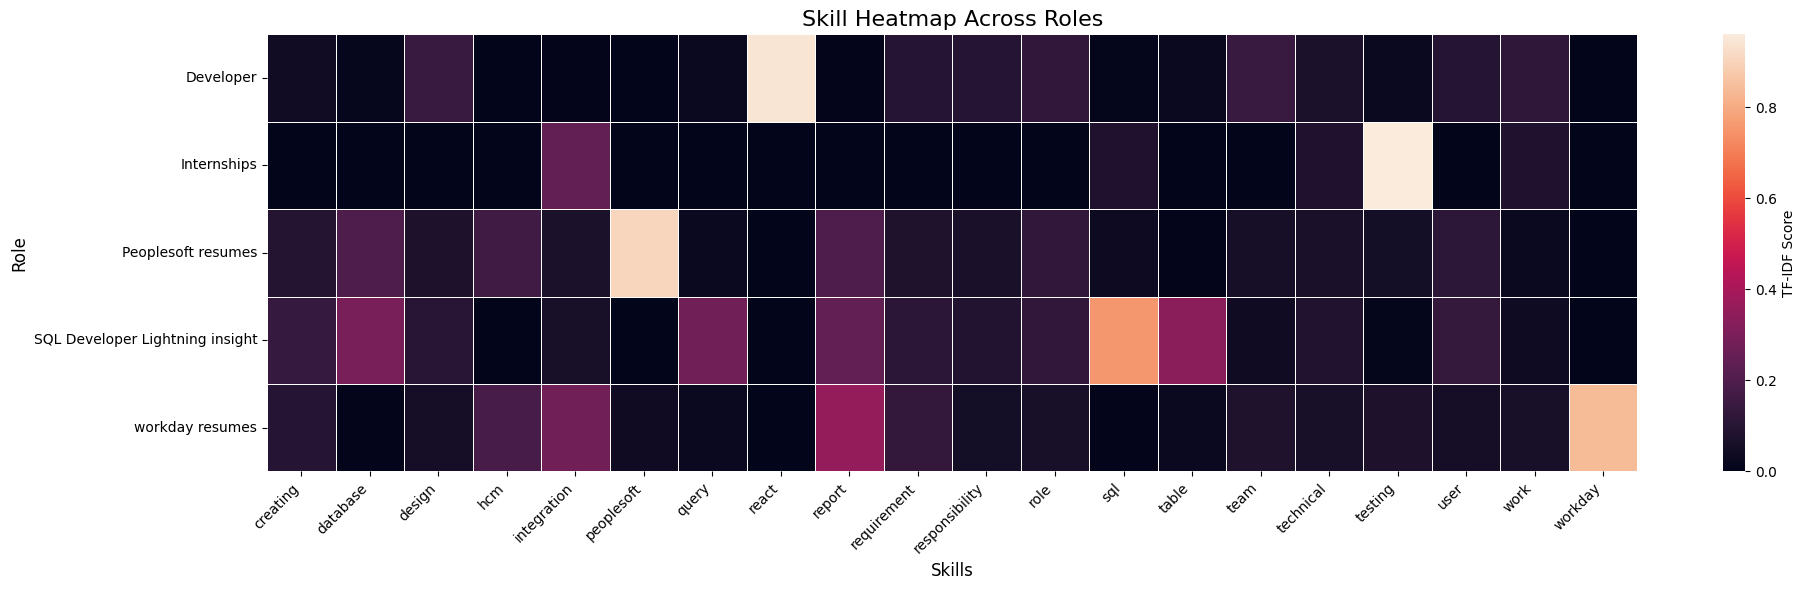

In [52]:
role_texts = df.groupby('role')['clean_resume'].apply(lambda x: ' '.join(x))

tfidf = TfidfVectorizer(max_features=20)
X = tfidf.fit_transform(role_texts)

heatmap_df = pd.DataFrame(
    X.toarray(),
    index=role_texts.index,
    columns=tfidf.get_feature_names_out()
)

plt.figure(figsize=(20, 6))

sns.heatmap(
    heatmap_df,
    cmap='rocket',
    annot=False,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 1, 'label': 'TF-IDF Score'}
)

plt.title("Skill Heatmap Across Roles", fontsize=16)
plt.ylabel("Role", fontsize=12)
plt.xlabel("Skills", fontsize=12)
plt.xticks(rotation=45, ha='right')  # rotate x-axis labels for readability
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#The heatmap shows skill importance across roles.

Light cells: Skill is highly relevant and important for that role.

Dark cells: Skill is weakly related or not important for that role.

#### RESUME SIMILARITY VISUALIZATION

In [53]:
tfidf_all = TfidfVectorizer(max_features=3000)
X_all = tfidf_all.fit_transform(df['clean_resume'])

similarity = cosine_similarity(X_all)

pca = PCA(n_components=2)
coords = pca.fit_transform(similarity)


# Encode role labels
le = LabelEncoder()
role_labels = le.fit_transform(df['role'])


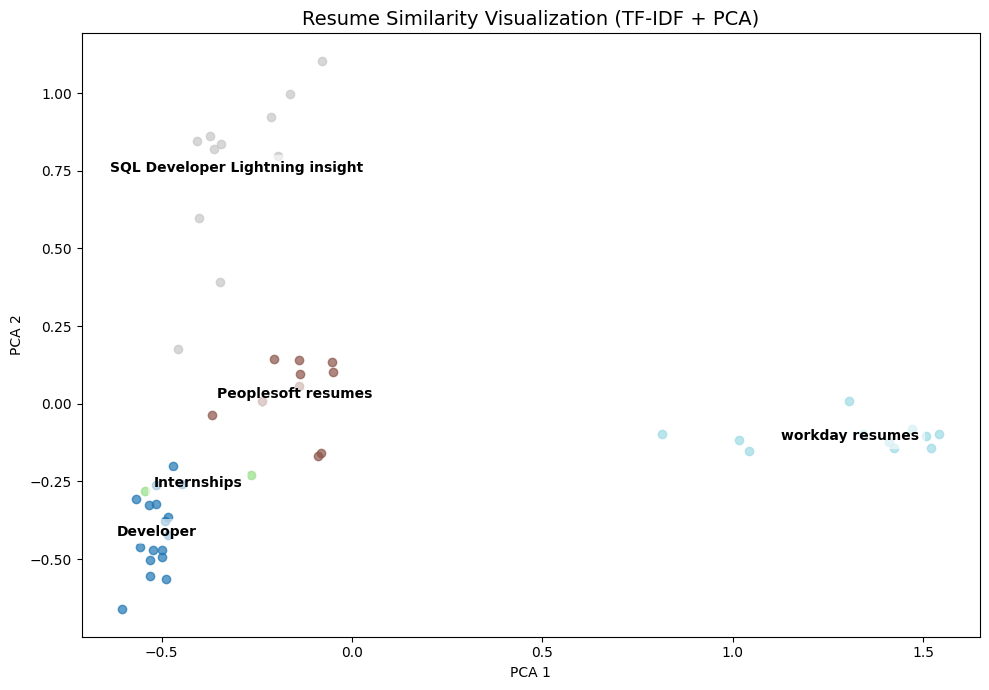

In [54]:
#PCA for Resume Visualization
plt.figure(figsize=(10, 7))

unique_roles = le.classes_
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_roles)))

for i, role in enumerate(unique_roles):
    idx = df['role'] == role

    plt.scatter(
        coords[idx, 0],
        coords[idx, 1],
        color=colors[i],
        alpha=0.7,
        label=role
    )

    # ---- place label at cluster center ----
    x_mean = coords[idx, 0].mean()
    y_mean = coords[idx, 1].mean()

    plt.text(
        x_mean,
        y_mean,
        role,
        fontsize=10,
        weight='bold',
        ha='center',
        va='center',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

plt.title("Resume Similarity Visualization (TF-IDF + PCA)", fontsize=14)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.tight_layout()
plt.show()

#used PCA to reduce similarity data to 2D and plotted resumes. Similar resumes cluster together visually

In [ ]:
# PeopleSoft resumes are scattered due to high internal skill diversity
# across modules, tools, and experience levels.


#### SKILL OVERLAP BETWEEN ROLES (CONFUSION RISK)

In [55]:
from itertools import product

roles = df['role'].unique()

def skill_set(role):
    text = ' '.join(df[df['role'] == role]['clean_resume'])
    return set(text.split())

jaccard = pd.DataFrame(index=roles, columns=roles, dtype=float)

for r1, r2 in product(roles, roles):
    s1 = skill_set(r1)
    s2 = skill_set(r2)
    jaccard.loc[r1, r2] = len(s1 & s2) / len(s1 | s2)


#Jaccard Skill Similarity
#Jaccard similarity measures skill overlap between roles.
#It calculates common skills divided by total skills.”



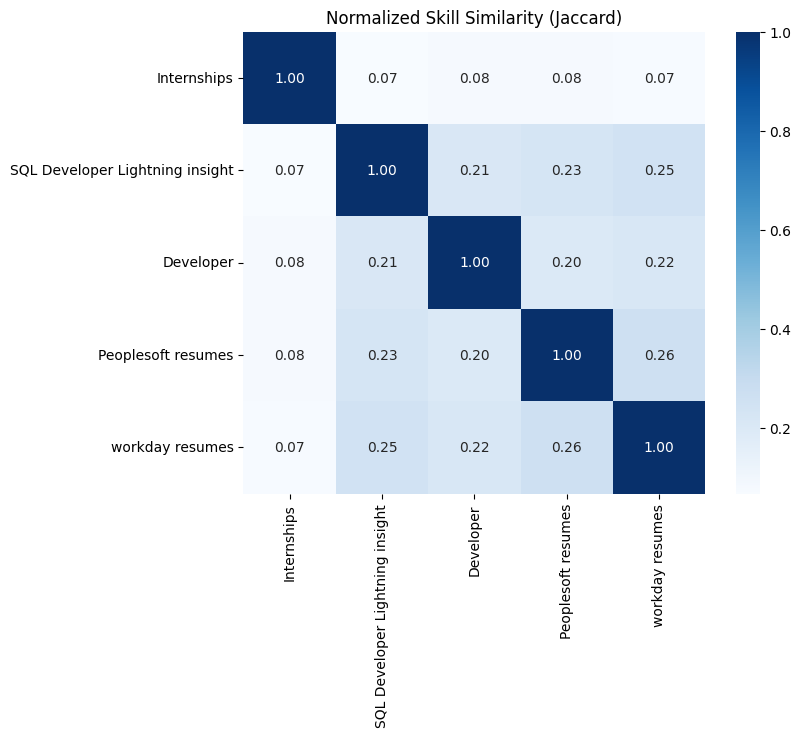

In [56]:
plt.figure(figsize=(8,6))
sns.heatmap(
    jaccard,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    square=True
)
plt.title("Normalized Skill Similarity (Jaccard)")
plt.show()

#Jaccard Heatmap
#This heatmap shows how similar roles are based on shared skills.
#Higher values mean stronger overlap.”

In [57]:
df.head()

,resume_text,role,clean_resume
0,curriculum vitae specialization computer engg ...,Internships,curriculum vitae specialization computer engg ...
1,susovan bag seeking challenging position field...,Internships,susovan bag seeking challenging position field...
2,raju pavana kumari professional summary profes...,SQL Developer Lightning insight,raju pavana kumari professional summary profes...
3,kamballa pradeep synopsis looking forward aspi...,SQL Developer Lightning insight,kamballa pradeep synopsis looking forward aspi...
4,anil kumar maddukuri sql msbi summary sql ssms...,SQL Developer Lightning insight,anil kumar maddukuri sql msbi summary sql ssms...
